In [92]:
from rocketcea.cea_obj_w_units import CEA_Obj
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [93]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 8,
    "axes.titlesize": 8, 
    "axes.labelsize": 8,
    "legend.fontsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

cea = CEA_Obj(
    oxName='LOX',
    fuelName='RP-1',
    pressure_units='bar',
    cstar_units='m/s',
    temperature_units='K',
    fac_CR=2.5
)

Pc = 110.0
eps = 16.0

In [94]:
rows = []

for MR in np.linspace(1.5, 4.5, 61):
    # shifting equilibrium
    Isp_eq = cea.get_Isp(Pc=Pc, MR=MR, eps=eps, frozen=0)

    # frozen from throat
    Isp_fr, cstar_fr, Tc_fr = cea.get_IvacCstrTc(
        Pc=Pc,
        MR=MR,
        eps=eps,
        frozen=1,
        frozenAtThroat=1
    )

    # chamber molecular weight
    mw_chm, gam_chm = cea.get_Chamber_MolWt_gamma(Pc=Pc, MR=MR, eps=eps)

    rows.append({
        "MR": MR,
        "Isp_eq_s": Isp_eq,
        "Isp_fr_s": Isp_fr,
        "cstar_fr_mps": cstar_fr,
        "Tc_K": Tc_fr,
        "MW_chamber": mw_chm
    })

df = pd.DataFrame(rows)
print(df)

      MR    Isp_eq_s    Isp_fr_s  cstar_fr_mps         Tc_K  MW_chamber
0   1.50  294.428274  291.087850   1650.429689  2508.089750   17.701725
1   1.55  298.562456  295.853282   1673.490407  2617.622057   18.046823
2   1.60  302.585164  300.198106   1694.364134  2722.160079   18.388344
3   1.65  306.435789  304.147199   1713.212158  2821.554675   18.725523
4   1.70  310.066709  307.721908   1730.166200  2915.675539   19.057636
..   ...         ...         ...           ...          ...         ...
56  4.30  315.356116  300.275619   1656.714566  3648.724677   27.592074
57  4.35  314.578216  299.588764   1652.912135  3642.356564   27.669780
58  4.40  313.804901  298.907920   1649.147616  3635.927616   27.746036
59  4.45  313.036049  298.232999   1645.420289  3629.441884   27.820877
60  4.50  312.271531  297.563909   1641.729424  3622.903080   27.894336

[61 rows x 6 columns]


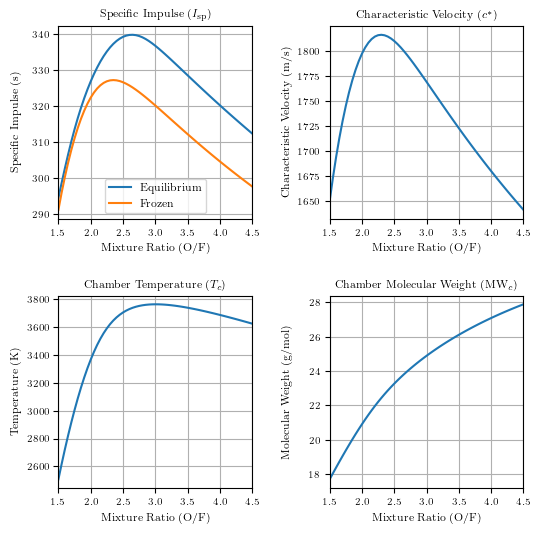

In [101]:
fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[0, 1])
ax4 = fig.add_subplot(gs[1, 1])

ax1.set_title(r"Specific Impulse ($I_\mathrm{sp}$)")
ax1.plot(df["MR"], df["Isp_eq_s"], label="Equilibrium")
ax1.plot(df["MR"], df["Isp_fr_s"], label="Frozen")
ax1.set_xlabel("Mixture Ratio (O/F)")
ax1.set_ylabel("Specific Impulse (s)")
ax1.legend()

ax2.set_title(r"Chamber Temperature ($T_c$)")
ax2.plot(df["MR"], df["Tc_K"], label="chamber temperature")
ax2.set_xlabel("Mixture Ratio (O/F)")
ax2.set_ylabel("Temperature (K)")

ax3.set_title(r"Characteristic Velocity ($c^*$)")
ax3.plot(df["MR"], df["cstar_fr_mps"], label="frozen c*")
ax3.set_xlabel("Mixture Ratio (O/F)")
ax3.set_ylabel("Characteristic Velocity (m/s)")

ax4.set_title(r"Chamber Molecular Weight ($\mathrm{MW}_c$)")
ax4.plot(df["MR"], df["MW_chamber"], label="molecular weight of chamber")
ax4.set_xlabel("Mixture Ratio (O/F)")
ax4.set_ylabel("Molecular Weight (g/mol)")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlim(1.5, 4.5)
    ax.grid(True, which="major")

fig.align_ylabels()

fig.savefig('parameters.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [99]:
MR_st = cea.getMRforER(ERphi=1.0)

print(f"MR at stoichiometric conditions: {MR_st:.2f}")

idx_max_isp_eq = df["Isp_eq_s"].idxmax()
isp_eq_max = df['Isp_eq_s'][idx_max_isp_eq]
mr_max_isp_eq = df['MR'][idx_max_isp_eq]
phi_max_isp_eq = MR_st / mr_max_isp_eq

idx_max_isp_fr = df["Isp_fr_s"].idxmax()
isp_fr_max = df['Isp_fr_s'][idx_max_isp_fr]
mr_max_isp_fr = df['MR'][idx_max_isp_fr]
phi_max_isp_fr = MR_st / mr_max_isp_fr

print(f"Maximum Isp (equilibrium): {isp_eq_max:.2f}s at MR = {mr_max_isp_eq:.2f} (φ = {phi_max_isp_eq:.2f})")
print(f"Maximum Isp (frozen): {isp_fr_max:.2f}s at MR = {mr_max_isp_fr:.2f} (φ = {phi_max_isp_fr:.2f})")

MR at stoichiometric conditions: 3.40
Maximum Isp (equilibrium): 339.69s at MR = 2.65 (φ = 1.28)
Maximum Isp (frozen): 327.11s at MR = 2.35 (φ = 1.45)
